# Error-model experiments on the Kunlun **[[18,4,4]]** — report

How does the full circuit noise decompose into its parts? Using the three fail-fast techniques (from
`three_techniques_18_4_4.ipynb`) **together with direct Monte-Carlo**, we compare the error models on
the *same* [[18,4,4]] code:

| model | noise kept |
|---|---|
| **full symmetric** | everything — `DEPOLARIZE1` + `DEPOLARIZE2` + `X_ERROR` |
| **CZ only** | `DEPOLARIZE2` (two-qubit `CX` gate depolarizing) |
| **meas only** | `X_ERROR` immediately **before** a measurement `M` |
| **prep only** | `X_ERROR` immediately **after** a reset `R` (state preparation) |
| **gate idle** | `DEPOLARIZE1` on data during the one **CX layer** each data qubit sits out |
| **meas idle** | `DEPOLARIZE1` on data during the **ancilla measure+reset stage** |

Channels are isolated by **filtering noise instructions** on one `symmetric(p)` circuit — every variant
uses the *identical* per-location rate `p` — via `bb_code_sim.filter_noise_channel` (predicates live
next to the circuit builder whose layout they encode). `X_ERROR` splits by position into *prep* (after
`R`) and *meas* (before `M`); `DEPOLARIZE1` is *idle* noise except right after an `H` (the 1q-gate
error), split into `gate_idle` / `meas_idle` by schedule position.

**Idle occupancy.** In the depth-7 schedule each data qubit is idle in **2 of the 8 rounds** per
syndrome cycle — round 7 (all data idle while ancillas are measured/reset) plus exactly one of rounds
0/6. So a data qubit picks up idle `DEPOLARIZE1(p)` **twice per cycle** (`1−(1−p)² ≈ 2p`, not `3p`).
The two slots are **separate channels**: on hardware the measure+reset dead time is much longer than a
gate, so device-faithful duration weighting (t_meas ≫ t_gate) belongs on the `meas_idle` rate.

**This notebook is a report.** Every simulation result is loaded from
`runs/error_model_comparison_18_4_4/`, produced (and cached task-by-task) by
`experiments/methods/run_error_model_comparison.py`. To refresh the data, run that script — it
recomputes only tasks whose cache is missing or whose configuration changed — then re-execute this
notebook (seconds; it needs neither stim nor a decoder).

## Setup — load the cached runner results

In [1]:
# All loading, estimators, tables and figures live in src/emc_report.py (the
# analysis layer, one method per cell of this report); R holds the cross-cell state.
from emc_report import Report

R = Report("error_model_comparison_18_4_4_device_baseline18_ghw72")  # results dir baked in at generation time
R.dem_counts()

full symmetric  : 1062 DEM mechanisms
CZ only         : 1062 DEM mechanisms
meas only       : 45 DEM mechanisms
prep only       : 45 DEM mechanisms
gate idle       : 72 DEM mechanisms
meas idle       : 72 DEM mechanisms


In [2]:
R.runner_times()   # cached per-task wall time, grouped by section

section                      tasks    wall time   newest result
setup + §0 schedule              3         0.2s   2026-07-28T19:08:02
§1 distances/onsets              6         9.7s   2026-07-28T19:12:06
§2 spectra (Technique I)         6        34.2s   2026-07-31T16:02:05
§3 splitting                     6       168.0s   2026-07-31T16:02:27
§4 direct MC                     6        68.7s   2026-07-31T16:02:31
§5 ablations (18)               15       197.6s   2026-07-31T16:05:49
§7 [[72,4,8]] sweeps            18    27,232.7s   2026-07-31T19:43:16
§7.5 72-code ablations           5    38,139.2s   2026-08-01T02:49:19
§8 asymmetric point             12    44,406.0s   2026-08-01T13:27:37
TOTAL                                110,256.3s   (§6 is pure analysis — no runner tasks)


## §0 — The syndrome-extraction schedule, up close

One cycle of the extraction circuit, layer by layer, for two data qubits (one per block) and one
ancilla of each type — derived from the built circuit itself (by the runner), so it is exactly the
layout the noise-channel predicates key on. Inline `·channel` tags show how each noise instruction is
classified (`cz` / `meas` / `prep` / `gate_idle` / `meas_idle`): each data qubit is busy in six of
the seven CX layers, idles through the one it sits out (`·gate_idle`), and idles again while the
ancillas are measured and reset (`·meas_idle`). The second cell renders the NOISY one-cycle schedule
as a stim `timeline-svg` diagram, sliced to a closed 7-qubit star — one data qubit plus its six check
ancillas, gates kept only when both endpoints are inside — so every rail shown is fully involved and
the labelled noise boxes are readable.

In [3]:
R.schedule_table()

layer |       data q0 (L)        |       data q9 (R)        |        X-anc q18         |        Z-anc q27        
--------------------------------------------------------------------------------------------------------------------
    0 |         R ·prep          |         R ·prep          |            —             |         R ·prep         
    1 |        ·gate_idle        |        CX→30 ·cz         |   R ·prep H ·(1q gate)   |        CX←15 ·cz        
    2 |        CX←18 ·cz         |        CX→29 ·cz         |         CX→0 ·cz         |        CX←10 ·cz        
    3 |        CX→28 ·cz         |        CX←18 ·cz         |         CX→9 ·cz         |         CX←2 ·cz        
    4 |        CX→27 ·cz         |        CX←20 ·cz         |        CX→10 ·cz         |         CX←0 ·cz        
    5 |        CX→33 ·cz         |        CX←21 ·cz         |        CX→15 ·cz         |         CX←3 ·cz        
    6 |        CX←24 ·cz         |        CX→27 ·cz         |         CX→3 ·cz       

rails: q0 = data q0   q1 = X-anc q18   q2 = X-anc q19   q3 = X-anc q24   q4 = Z-anc q27   q5 = Z-anc q28   q6 = Z-anc q33
noise tags: cz = navy   meas = seagreen   prep = darkorange   gate_idle = purple   meas_idle = mediumvioletred   1q gate = gray


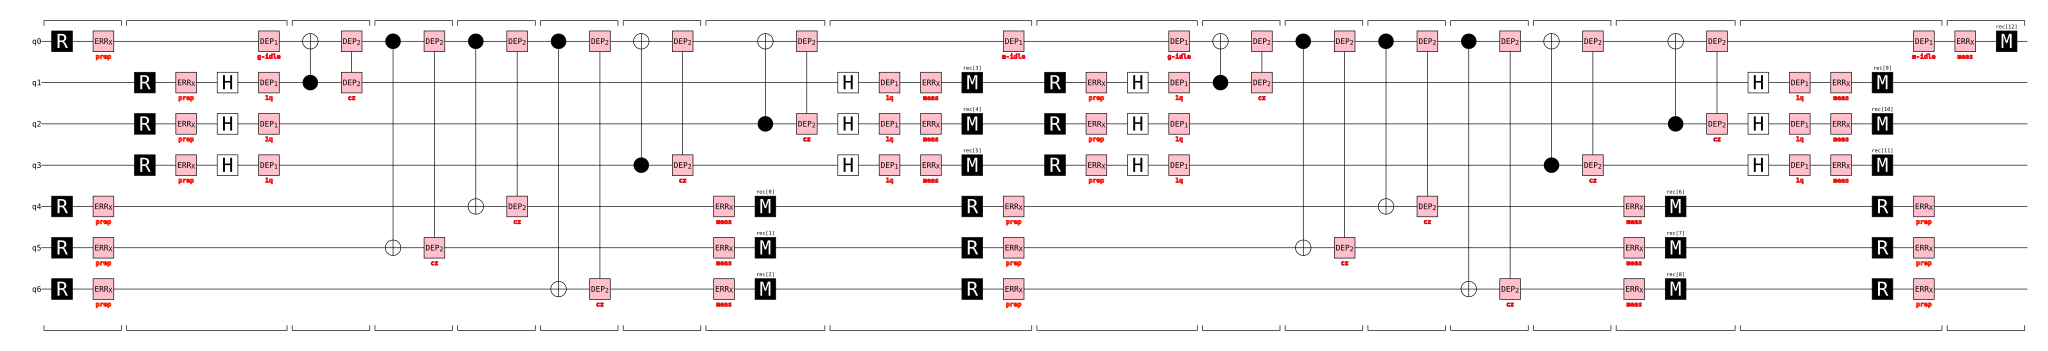

In [4]:
R.schedule_svg()   # noise boxes tagged/colored by channel; see the method docstring

## §1 — Technique II: distance, onset, perfect-decoder floor (per model)

For each model: circuit fault distance `D`, onset weight `w₀=⌈D/2⌉`, the exact `L(D)`, and the
perfect-decoder onset fraction `f₀*`. The four *isolated* channels (CZ / meas / prep / idle) each turn
out to have **even** distance 4 (the code distance) — so `f₀*` is exact via Proposition 1 — while the **full**
model has **odd** distance 3: only *combining* channels makes the weight-3 hook that drops it below the
code distance (Appendix A.6 route for `f₀*`). `L(D)` is enumerated with the ldpc-free half-MITM for even
`D` (robust) and the coset search for odd `D`.

In [5]:
R.tech2_table()

model             D  w0   #DEM   |L(D)|      f0*   route
full symmetric    3   2   1062       23   0.0196   App.A.6 (odd D)
CZ only           4   2   1062     7542   0.0132   Prop.1 (even D)
meas only         4   2     45       45   0.0629   Prop.1 (even D)
prep only         4   2     45       45   0.0629   Prop.1 (even D)
gate idle         4   2     72       90   0.0449   Prop.1 (even D)
meas idle         4   2     72      135   0.1348   Prop.1 (even D)

⏱ runner: 10 s wall over 6 tasks (newest 2026-07-28T19:12:06)


## §2 — Technique I: failure-spectrum ansatz (per model)

The runner importance-samples the failure spectrum `f(w)` (adaptive 'hit N failures per weight'
allocation; the weight window is sized per model from the binomial mass at the top of the `p` grid,
so the reweighted curves carry no truncation sag anywhere on the grid) and fits the f5 ansatz (onset
`w₀` left free). The report loads both: the measured spectrum drives every point value below (via
binomial reweighting), the fit supplies the smooth `LER(p)` curves.

**Decoder convention (device calibration).** Every estimator in this report shares ONE decoder
(Relay-BP, `num_sets=20`) whose priors are frozen from the task's noise model built at the
**evaluation point** `p* = 5×10⁻⁴` (`DECODER_P` in the runner) — not at the sampling reference
`p_ref = 0.01`. This is the device convention: a real decoder is calibrated to device rates.
It matters because wrong-coset *pair* explanations scale ∼p² against a true single fault's ∼p —
at p_ref-priors, meas-pair explanations of the ×5 mix's weight-1 CZ hooks were up to 7.5× likelier
than the truth (Bayes-rational misdecodes); calibrated at `p*` the same decoder catches every
single fault (breakeven `p ≈ 1.3×10⁻³`). `f(w)` remains rate-independent because the decoder is
*fixed* — but curves above breakeven (the direct-MC anchors, the threshold crossings) describe a
decoder deliberately miscalibrated for that regime, so expect slightly elevated MC points and
slightly lower pseudo-thresholds than a per-point-calibrated decoder would give.

In [6]:
R.load_spectra()

full symmetric  : w=1..32, measured f(2)=0.0283 (33117 shots total)   f5 fit cost=19.53
CZ only         : w=1..20, measured f(2)=0.0284 (27798 shots total)   f5 fit cost=10.98
meas only       : w=1..10, measured f(2)=0.0572 (12885 shots total)   f5 fit cost=0.99
prep only       : w=1..10, measured f(2)=0.0677 (10216 shots total)   f5 fit cost=4.02
gate idle       : w=1..10, measured f(2)=0.0646 (11100 shots total)   f5 fit cost=3.00
meas idle       : w=1..10, measured f(2)=0.1270 (5747 shots total)   f5 fit cost=1.66

⏱ runner: 34 s wall over 6 tasks (newest 2026-07-31T16:02:05)


## §3 — Technique III: replica-exchange splitting (per model)

Splitting reaches deep into the rare regime, seeded by each model's exact `L(D)` from §1.

In [7]:
R.load_splitting()

full symmetric  : swap-accept 0.65..0.95   P(1e-4)=1.34e-05
CZ only         : swap-accept 0.75..0.98   P(1e-4)=5.44e-06
meas only       : swap-accept 0.88..1.00   P(1e-4)=9.69e-07
prep only       : swap-accept 0.89..1.00   P(1e-4)=8.77e-07
gate idle       : swap-accept 0.87..1.00   P(1e-4)=1.91e-07
meas idle       : swap-accept 0.90..1.00   P(1e-4)=5.64e-07

⏱ runner: 168 s wall over 6 tasks (newest 2026-07-31T16:02:27)


## §4 — Direct Monte-Carlo + overlay

Direct-MC ground truth at moderate `p`, overlaid with all three techniques. Per model the ansatz
line, the splitting squares, and the MC circles should coincide where they overlap. (MC only
*validates* the curves — the budget never reads it — so the runner's `MC_SCALE` trades error-bar
width for minutes.)

   p         full symmetric        CZ only      meas only      prep only      gate idle      meas idle
  0.030         8.603e-01      6.082e-01      6.683e-02      7.317e-02      2.400e-02      5.650e-02
  0.012         3.786e-01      1.473e-01      1.183e-02      1.150e-02      3.667e-03      8.167e-03
  0.008         1.898e-01      6.211e-02      5.611e-03      4.944e-03      2.111e-03      3.722e-03
  0.005         7.623e-02      2.180e-02      2.433e-03      2.000e-03      8.667e-04      1.467e-03
  0.003         2.456e-02      7.333e-03      5.778e-04      9.111e-04      1.778e-04      5.333e-04

⏱ runner: 69 s wall over 6 tasks (newest 2026-07-31T16:02:31)


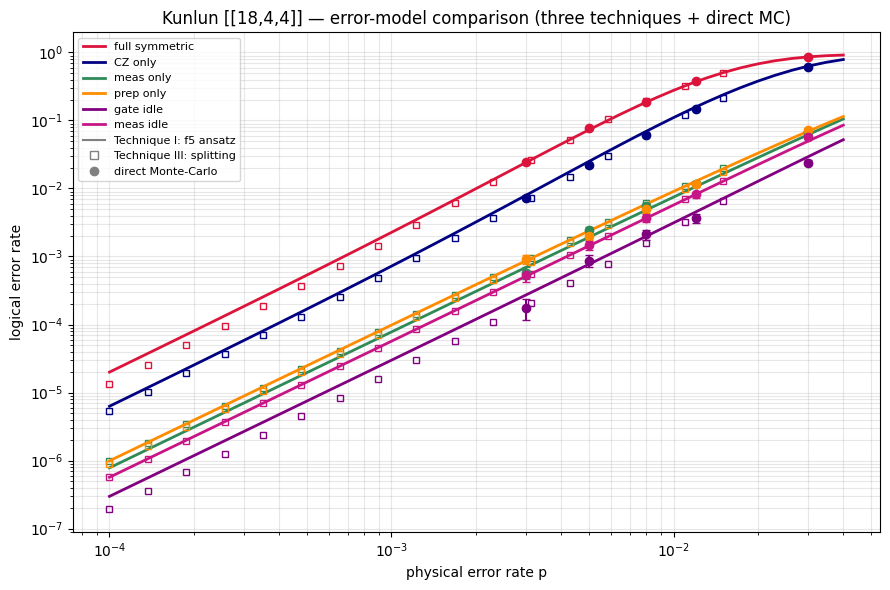

In [8]:
R.mc_overlay()

## §5 — Ablation (leave-one-out): the marginal channel contributions

Google's Willow error budget (arXiv:2408.13687) is built from **marginal** contributions — remove (or
scale) one error component in simulation and measure how much the logical error rate drops. The
channel-*isolated* circuits of §1–§4 cannot provide this: §1 showed every isolated channel has even
distance **4** while the full model has odd distance **3**, so the dominant low-`p` failures are
**mixed-channel** faults that no isolated circuit contains. The runner puts the five **all-but-one**
models (`keep = not channel`) through the same pipeline.

The ablated distances are a structural diagnostic: if dropping channel *i* restores `D=4`, then
channel *i* participates in **every** weight-3 hook; if `D` stays 3, the hooks survive without it.

In [9]:
R.tech2_abl_table()

model          D  w0   #DEM   |L(D)|        f0*   hook diagnosis
no CZ          4   2    117      180  2.825e-02   restores D=4 -> channel is in EVERY weight-3 hook
no meas        3   2   1062       24  1.847e-02   still D=3 -> hooks survive without this channel
no prep        3   2   1062       23  2.154e-02   still D=3 -> hooks survive without this channel
no gate idle   3   2   1062       15  1.727e-02   still D=3 -> hooks survive without this channel
no meas idle   3   2   1062       13  1.626e-02   still D=3 -> hooks survive without this channel


In [10]:
R.load_ablations()

no CZ        : f5 fit cost=10.64   MC LER(p=0.003) = 5.600e-03
no meas      : f5 fit cost=17.56   MC LER(p=0.003) = 1.916e-02
no prep      : f5 fit cost=16.64   MC LER(p=0.003) = 2.089e-02
no gate idle : f5 fit cost=16.99   MC LER(p=0.003) = 1.889e-02
no meas idle : f5 fit cost=8.47   MC LER(p=0.003) = 1.807e-02

⏱ runner: 198 s wall over 15 tasks (newest 2026-07-31T16:05:49)


## §6 — The error budget (Willow-style)

Willow's budget reads `1/Λ ≈ Σᵢ pᵢ/p_th,i` — each channel priced against its own threshold. Two
honesty notes for a **single** code:

* There is no Λ (it is a ratio between code *sizes*); the single-code stand-in for `p_th,i` is the
  channel **pseudo-threshold** — the break-even `p` where `LER_i(p) = p`. A *true* Λ needs the
  same-polynomial `(l,m)=(6,6)` sibling **[[72,4,8]]** (`A=1+x+y²`, `B=1+y+x²`, exact d=8) — §7.
* Two decompositions of `LER_full` are shown, and they differ by construction:
  **isolated** `LER_i/LER_full` (misses mixed faults; the deficit is the **mixing bucket**) and
  **marginal** `1 − LER_{no i}/LER_full` (Google's convention; Σ typically **exceeds 1** because a
  mixed fault is killed by removing *any* of its participant channels, so it is counted in each).
  SPAM = meas + prep (their linear budget terms add).

Point values at `p*` come from the MEASURED spectra, binomially reweighted — NOT from the f5 fits
(independently-fitted extrapolations drift apart model-to-model down here and can even invert the
full-vs-ablated ordering into negative "marginals"). The fits still supply the curve-wide
pseudo-thresholds, where they are anchored. The marginal column carries the propagated binomial
`±σ`. Cross-check column: Technique III splitting (§3 reaches p=1e-4; direct MC is impractical at
LERs of 1e-4..1e-6).

In [11]:
R.budget_table()

error budget at p* = 0.0005   (LER_full: reweighted 5.491e-04, splitting 4.007e-04)
channel       isolated iso(split)  marginal     ±σ     p_pth  p*/p_pth
CZ only          0.293      0.358     0.757  0.028    0.0013     0.376
meas only        0.037      0.060     0.180  0.086    0.0136     0.037
prep only        0.044      0.054     0.180  0.097    0.0112     0.045
gate idle        0.013      0.012     0.199  0.085    0.0307     0.016
meas idle        0.026      0.035     0.195  0.088    0.0177     0.028
mixing           0.587                             (1 - sum isolated: cross-channel faults)
SPAM             0.081                0.361         (meas + prep combined)
idle total       0.039                0.394         (gate + meas idle combined)
sum(marginal) = 1.511  (>1 <=> shared mixed faults; Google renormalizes)
Willow-form sum: 0.502 = 0.376 (CZ) + 0.037 (meas) + 0.045 (prep) + 0.016 (gate idle) + 0.028 (meas idle)   [all terms < 1: genuinely sub-threshold]


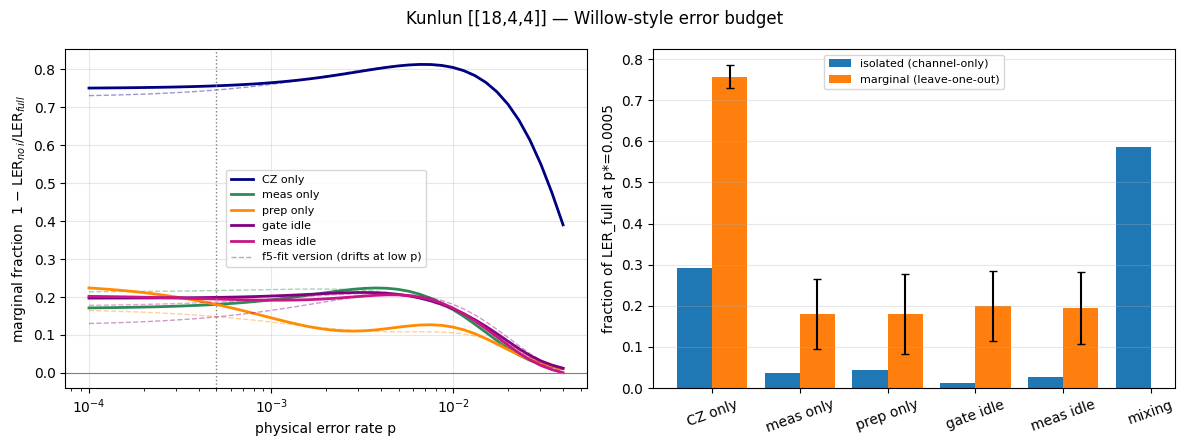

In [12]:
R.fig_budget()

## §7 — The true Λ: five channels on the [[72,4,8]] sibling

Everything so far used *pseudo*-thresholds because a real threshold is a crossing between code
sizes. The Kunlun polynomials give a distance-scaled partner: **[[72,4,8]]** at `(l,m)=(6,6)` —
same `A = 1+x+y²`, `B = 1+y+x²`, `k=4`, code distance **8 exact** (both sectors: `w≤7` eliminated by
complete split-MITM, weight-8 logicals exhibited). `d: 4 → 8` is two `+2` steps, the K=4 analog of
Google's `d=3,5,7` ladder.

**Conventions.** Rounds scale with distance (`d/2`: 2 rounds for d=4, 4 for d=8), and Λ compares
**per-round** logical error rates `ε(p) = 1 − (1−LER)^{1/rounds}`: `Λ_i(p) = ε₁₈,ᵢ(p)/ε₇₂,ᵢ(p)`.
The channel crossings `ε₁₈,ᵢ = ε₇₂,ᵢ` are the *true* per-channel thresholds `p_th,i` that the
Willow budget divides by. No exact `f₀*` at this size (the `L(D)`/`L(D+1)` enumerations are the
bb144-regime problem) — the Λ budget doesn't need it.

**Cost.** The 144-qubit sweeps are the expensive part of the runner (order an hour+), which is
exactly why they are cached per task: a re-run of `run_error_model_comparison.py` touches them only
if their config changed. `--boost72` buys the 72-code spectra 2× target failures and 5× shots —
see the §7.5 box for when that is worth it.

In [13]:
R.tech2_72_table()

model             D   (circuit fault distance, BP-OSD upper bound; f0 unpinned at this size)
full symmetric    8
CZ only          10
meas only         8
prep only         8
gate idle         8
meas idle         8


In [14]:
R.load_spectra_72()

full symmetric  : weights 1..166 (90/91 sampled, 123401 shots), f5 fit cost=60.63, MC LER(0.008)=3.291e-01
CZ only         : weights 1..98 (56/57 sampled, 134259 shots), f5 fit cost=54.67, MC LER(0.008)=3.100e-02
meas only       : weights 1..30 (23/23 sampled, 146615 shots), f5 fit cost=9.18, MC LER(0.008)=0.000e+00
prep only       : weights 1..30 (22/23 sampled, 141726 shots), f5 fit cost=6.44, MC LER(0.008)=0.000e+00
gate idle       : weights 1..24 (19/20 sampled, 103513 shots), f5 fit cost=5.79, MC LER(0.008)=0.000e+00
meas idle       : weights 1..24 (19/20 sampled, 114974 shots), f5 fit cost=7.71, MC LER(0.008)=0.000e+00

⏱ runner: 27,233 s wall over 18 tasks (newest 2026-07-31T19:43:16)


### The measured failure spectra — every one of them, both codes

Every point value, budget fraction, and Λ in §6–§8 is a binomial reweighting of a sampled
spectrum, and the spectra are where estimator pathologies hide — so *all* of them are plotted
here (6 models + 5 leave-one-out mixes + 6 asymmetric mixes, per code). Reading guide: the
dashed vertical marks the full model's **predicted onset** `w₀ = ⌈D/2⌉` (computed from the tech2
circuit distance `D`) — the lowest weight at which even a **perfect** minimum-weight decoder can be
forced to misdecode. Dots *at or right of* it are **decoder-in-the-loop failures** that are
irreducible coset ambiguity (any decoder can be forced to misjudge them); dots *left of* `w₀` are
sub-onset decoder artifacts, and this report has eliminated both
known kinds — BP symmetry traps (fixed by `num_sets=20`) and prior-mismatch misdecodes of
trace-free hooks (fixed by calibrating the decoder at `p*` instead of `p_ref` — see the §2
decoder-convention note). A dot reappearing below `w₀` after a decoder or budget change is a
regression in one of those two categories. A **★ star** marks Technique II's *exact* perfect-decoder
onset fraction `f₀*` at `w₀` (`Prop.1` for even `D`, `App.A.6` for odd) — the measured onset dot sits
*above* it by the decoder's excess miscorrection at the onset. The ×5 asymmetric rays carry their
**own** `f₀*` (`compute_f0_asym_18.py`): `D`, `w₀` and the failing *sets* are ray-independent, but the
onset *fraction* is not — mechanisms enter the expanded-uniform measure with rate-proportional
multiplicities, so the ×5 ray re-weights the same failing sets (≈1.6–2.2× the symmetric values here).
The **[[72,4,8]]** onset fraction is
**unpinned** (no exact `L(D)` at 144 qubits), so those panels instead carry a rigorous **lower bound**
`f₀* ≥ f0_lower` (open **▲**, from a partial-`L(D)` search — `compute_f0_lower_72.py`, and
`compute_f0_lower_asym_72.py` for the ×5 mixes, whose bound is re-weighted by the ×5 multiplicities;
for the *ablated* ×5 mixes even `D` is a BP-OSD upper bound computed there) alongside the
onset-**weight** line; the measured onset dot is the matching upper bound, so f₀* lies between the ▲
and the first dot (the bound is loose — it tightens only with far more enumerated logicals). The thin dashed curves are the **f5 ansatz** (Eq. 10
of the paper; stored fits for the models, fitted here on the cached bins for the mixes): it is
identically zero below its fitted `w₀`, so a dot the dashed curve structurally cannot reach is
outside the ansatz family — the decoder-floor signature at a glance. **× marks** are sampled
bins with zero observed failures (drawn at `1/(2T)`): empty low-`w` bins are what the §7.5/§8
truncation interval prices at `3/T`, so watch them whenever budgets change. The alternating
high-`w` gaps are the stride-2 tail sampling (see `emc_report.fill_spectrum`).

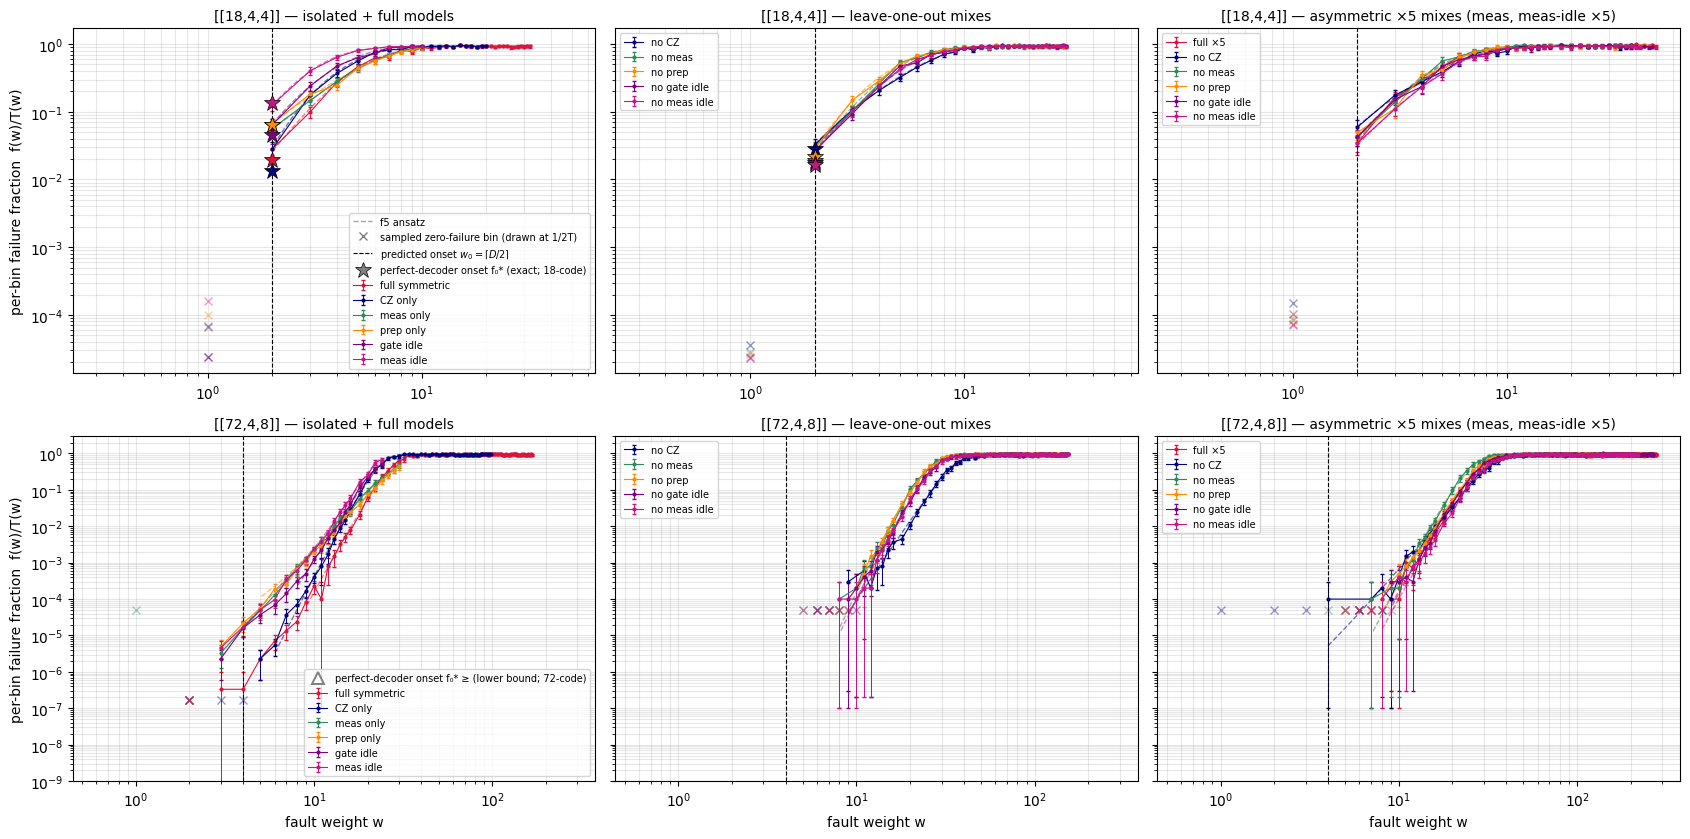

In [15]:
R.fig_spectrum_grid()   # every spectrum §6-§8 reweights, eyeballed in one figure

The grid above answers *how often does a weight-`w` fault defeat the decoder?*.
The companion below answers the complementary question: **when this code does fail, how
heavy was the fault?** Conditioning the weight distribution on failure — `P(W=w|p)·f(w)`,
normalised — gives the mean plotted here, with ±1 s.d. bands showing the spread of
failures (not uncertainty).

Two reference lines make it readable. The dotted grey line is the mean number of faults
in an *arbitrary* shot, `N·q`: failures sit well above it, because everything lighter is
corrected. The dashed line is the perfect-decoder onset `w₀`: a curve that sinks toward
or below it at low `p` is a decoder being killed by sub-onset configurations, which is
the floor this campaign set out to measure. A better decoder is defeated only by heavier
faults, so its curve sits **higher** even though it fails far less often.

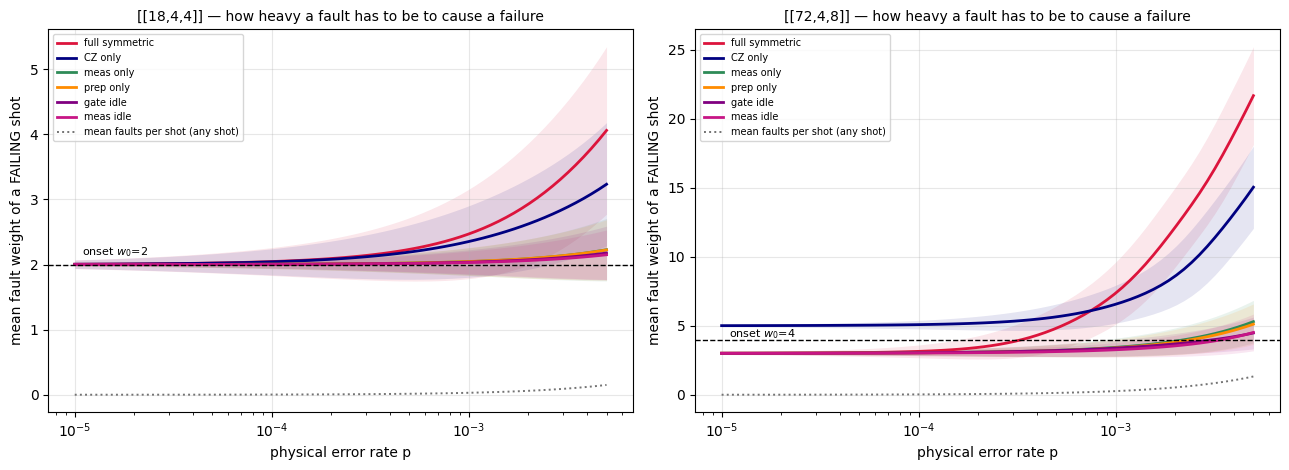

In [16]:
R.fig_weight_map()   # which fault weights carry the LER, versus p

### Where the ansatz stops describing the data

The `f5` ansatz encodes *code-limited* behaviour: a hard onset `w₀`, then a monotonic,
steep rise. What a real decoder produces below the onset is a **floor** — a roughly
constant miscorrection probability, because a decoder that mis-corrects three faults
tends to mis-correct four about as often. That shape is outside the family, so the fit
undershoots the lightest bins no matter how well it is optimised.

The consequence is directional and worth stating plainly: **below about `p = 1e-3` the
ansatz is optimistic**, because it assigns little or no probability to exactly the
sub-onset mass this campaign measured. Above that the two agree to within ~20%, since
the binomial mass then sits on weights the ansatz fits well.

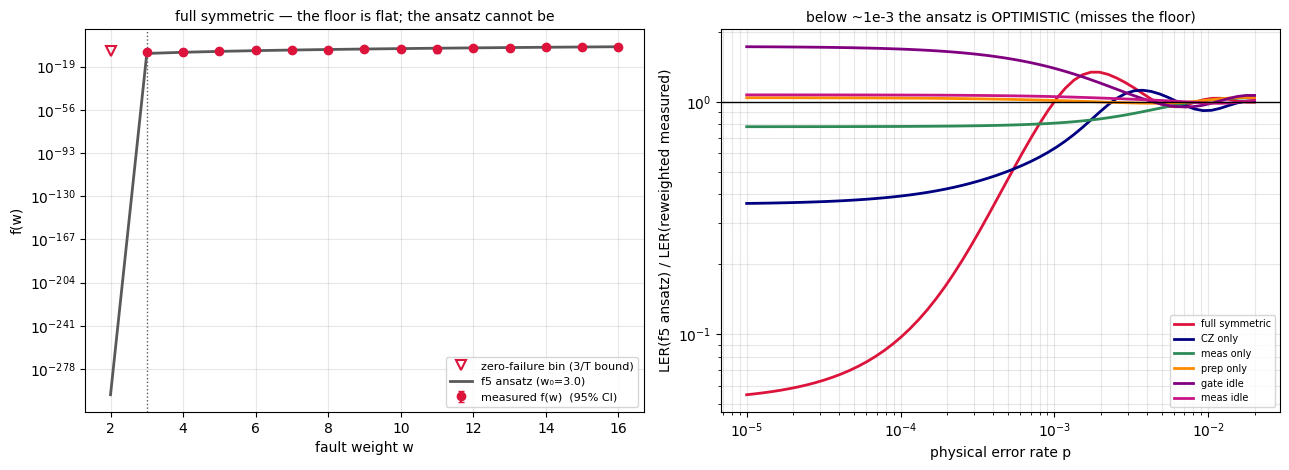

In [17]:
R.fig_ansatz_vs_measured()   # ansatz vs measured: the floor is flat, the ansatz cannot be

In [18]:
R.lambda_table()

channel           p_th (ε18=ε72)     Λ(p*)       ±σ    Λ(fit)   p*/p_th     (p* = 0.0005)
full symmetric            0.0227  7.73e+03  2.7e+03  2.75e+05     0.022
CZ only                   0.0372  5.85e+04  1.5e+04  2.36e+05     0.013
meas only                  >0.04  1.23e+04  3.3e+03   4.8e+04    <0.013
prep only                  >0.04  9.89e+03  2.3e+03  2.68e+05    <0.013
gate idle                  >0.04  1.48e+04  4.8e+03   1.9e+10    <0.013
meas idle                  >0.04   1.6e+04  4.1e+03  2.01e+07    <0.013

Λ_full(p*) = 7.73e+03  →  per-(+2-distance)-step λ = √Λ = 87.9  (d: 4→8 is two steps)
Willow identity check at p*: 1/Λ_full = 0.000  vs  Σᵢ p*/p_th,i = 0.013   (CZ 0.013, SPAM 0.000)
residual = mixed-channel faults (isolated channels cannot see them — see §1/§5); Σ < 1/Λ_full means the additive budget under-covers by that share.


C:\Users\aksirot_local\Desktop\workspace\general\stim_work\src\emc_report.py:50: RuntimeWarning: divide by zero encountered in log
  r = np.log(y1) - np.log(y2)


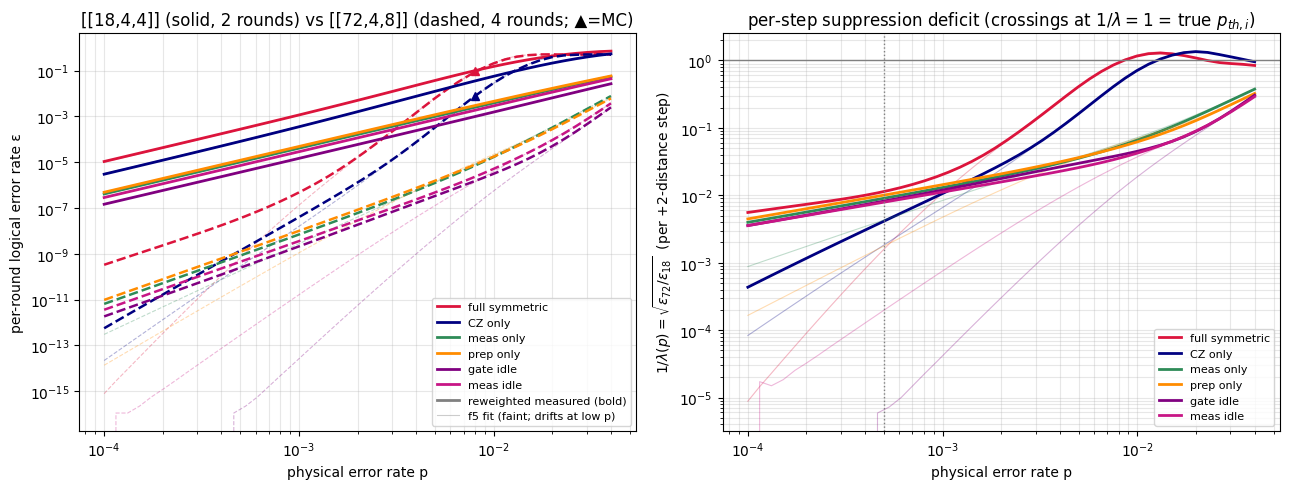

In [19]:
R.fig_74()   # bold = reweighted measured, faint = f5 fit (drifts at low p)

## §7.5 — Marginal Λ: the ablations on the larger code

§7.3's Λᵢ used channel-*isolated* circuits — the clean per-channel suppression capability, but not
a decomposition of Λ_full (the mixed-channel faults belong to no isolated circuit). Google's
budget convention is *marginal*: ablate one component from the FULL circuit and measure the
change. The runner runs the five leave-one-out circuits on **[[72,4,8]]** (the 18-code ablations
are §5's); we form `Λ_no-i(p*) = ε₁₈,no-i/ε₇₂,no-i` and read channel i's contribution to the full
suppression deficit as `1/Λ_full − 1/Λ_no-i`. The gap between Σ(contributions) and `1/Λ_full` is
the Λ-space mixing — the same story §6 tells in LER-space, now for error suppression.

**Reading the signs.** Each contribution is a *difference of two noisy ratios*, so this box now
carries the full uncertainty budget: `±σ` propagates the binomial errors of all four spectra, and
the `[lo, hi]` interval additionally spans the **zero-bin truncation** — every sampled-but-empty
weight bin priced at its rule-of-three upper bound `f(w) < 3/T`. That pricing deliberately
includes the bins *below* tech2's D: D is the perfect-decoder floor, but the measured spectra
show the actual decoder **miscorrects below it** (see the spectrum figure in §7 — `f(1) > 0` on
the full 18-code mix under a p_ref-calibrated decoder), so an empty low-`w` 72-code bin is
unresolved statistics, not a structural zero — and at low `p*` the reweighting is most sensitive
to exactly those bins. A negative share is only *real* (a channel whose faults the big code
handles better than the small one) if it stays negative within both; otherwise it is an estimator
artifact of the under-resolved [[72,4,8]] low-weight bins. `--boost72` tightens the onset
statistics; the truncation interval, however, shrinks only with more trials on the empty low-`w`
bins themselves (3/T), not with more onset failures.

In [20]:
R.load_ablations_72()

⏱ runner: 38,139 s wall over 5 tasks (newest 2026-08-01T02:49:19)


In [21]:
R.lambda_box_sym()

marginal Λ decomposition at p* = 0.0005   (Λ_full = 7.73e+03, 1/Λ_full = 1.294e-04)
channel       Λ_no-i(p*)   1/Λ_no-i  contribution        ±σ   share   verdict
CZ only         1.47e+07  6.785e-08     1.293e-04  4.54e-05    1.00   solid
meas only        1.1e+05  9.052e-06     1.203e-04  4.62e-05    0.93   sign not robust to zero-bin truncation
prep only       1.99e+06  5.018e-07     1.289e-04  4.54e-05    1.00   sign not robust to zero-bin truncation
gate idle       4.46e+05  2.240e-06     1.272e-04  4.55e-05    0.98   sign not robust to zero-bin truncation
meas idle       9.33e+04  1.072e-05     1.187e-04  4.66e-05    0.92   sign not robust to zero-bin truncation

sum of marginal contributions = 6.244e-04  vs  1/Λ_full = 1.294e-04   (ratio 4.83)
ratio > 1: shared mixed faults counted once per participant (as in §6's Σ marginal > 1).
A NEGATIVE contribution is physical only when 'solid': removing that channel genuinely
HURT the suppression ratio (the big code handles its faults better

## §8 — A second operating point: meas & meas-idle ×5

Everything above is a **sensitivity analysis at one base point in rate-space** — the symmetric ray
where every channel runs at the same p. The budget fractions are components of a gradient of
`1/Λ` (and of LER), and gradients depend on where you evaluate them. Real devices don't sit on
the symmetric ray: measurement error and the measure/reset dead-time idle typically run several
times hotter than gates. Here we re-evaluate at a device-like point — **meas and meas_idle at
5×p, everything else at p** (`scale_noise_channels`) — and redo the marginal budget and Λ.

Two economies: (i) the **isolated** curves need no resampling — `f(w)` is rate-independent, so
channel i at rate `rᵢ·p` is just `reweight_spectrum(spec_i, [rᵢ·p])`; only the full and ablated
*mixes* (whose channel composition changes) are new sweeps. (ii) Ablating channel i from the
asymmetric mix composes the existing tools: `filter_noise_channel(scale_noise_channels(...))`.
Convention: `p` remains the base rate of the un-boosted channels, so `p*` comparisons across
§6/§8 are at equal gate noise. The Λ box carries the same `±σ` / zero-bin verdicts as §7.5.

In [22]:
R.load_asym()

⏱ runner: 44,406 s wall over 12 tasks (newest 2026-08-01T13:27:37)


In [23]:
R.budget_box_asym()

budget at the ASYMMETRIC point (meas, meas_idle ×5), p* = 0.0005:
LER_full = 2.448e-03  (symmetric point: 5.491e-04 — the ×5 mix costs 4.5× in error rate)
channel       isolated  marginal     ±σ   vs symmetric    iso   marg
CZ only          0.066     0.215  0.120                 0.293  0.757
meas only        0.205     0.541  0.067                 0.037  0.180
prep only        0.010    -0.027  0.143                 0.044  0.180
gate idle        0.003    -0.020  0.147                 0.013  0.199
meas idle        0.146     0.447  0.081                 0.026  0.195
mixing           0.571                                0.587
sum(marginal) = 1.156   (symmetric: 1.511)


In [24]:
R.lambda_box_asym()

Λ_full(p*=0.0005) at the ×5 point: 1.47e+04 ± 7.5e+03   (symmetric: 7.73e+03)   per-step λ = 121 (symmetric: 87.9)
channel       Λ_no-i(p*)   1/Λ_no-i  contribution        ±σ   share   verdict
CZ only              428  2.339e-03    -2.271e-03  2.23e-03  -33.45   ~0 within 2σ (noise)
meas only       7.58e+03  1.320e-04    -6.408e-05  1.22e-04   -0.94   ~0 within 2σ (noise)
prep only       5.57e+03  1.797e-04    -1.118e-04  9.14e-05   -1.65   ~0 within 2σ (noise)
gate idle       1.05e+04  9.484e-05    -2.694e-05  5.46e-05   -0.40   ~0 within 2σ (noise)
meas idle       1.93e+04  5.173e-05     1.617e-05  5.46e-05    0.24   ~0 within 2σ (noise)

sum of marginal contributions = -2.458e-03  vs  1/Λ_full = 6.790e-05   (ratio -36.20)
ratio > 1: shared mixed faults counted once per participant (as in §6's Σ marginal > 1).
A NEGATIVE contribution is physical only when 'solid': removing that channel genuinely
HURT the suppression ratio (the big code handles its faults better than the small one).
'

### §8.4 — the §7.4 panels on the ×5 ray

The point-decomposition table above is noise-limited at `p* = 5e-4`; the *curves* are not — away
from the deep-suppression regime the same cached spectra resolve the ×5 story cleanly. This is the
§7.4 figure remade at the device-like point, with **no new sampling**: the full mix reweights its
own asymmetric spectra, and each isolated channel reweights its §2/§7.2 spectrum at its **own**
rate `rᵢ·p` (the x-axis stays the base rate `p` of the un-boosted channels, the §6/§8 convention).
Boosted channels are drawn only while `rᵢ·p ≤` the grid top their weight windows were sized for —
beyond that the reweighted curve sags from window truncation, not physics. Curves come in §7.4's
dual-estimator style: **bold** = reweighted measured spectra (lower-bound caveat at very low `p`),
**faint** = the f5-fit estimator on the same ray — isolated channels reuse their stored §2/§7 fits
shifted to `rᵢ·p` (same fit, scaled abscissa), while the full ×5 mix is fitted here on its cached
asym bins (the runner stores no fit for the asym sweeps). Where bold and faint split at low `p` is
the ansatz-vs-decoder-floor break: the fit is identically zero below its fitted `w₀`, the
reweighted sum keeps the measured sub-onset bins. The crossings table recomputes the symmetric-ray
values with the reweighted estimator for an apples-to-apples comparison.

true per-channel thresholds on the ×5 ray (base-p convention) vs the symmetric ray
channel           p_th ×5  p_th sym (rw)   note
full ×5 mix        0.0126         0.0228   
CZ only            0.0372         0.0372   
meas only        >0.00751          >0.04   ×5 channel: threshold in its OWN rate = 5×p_th
prep only           >0.04          >0.04   
gate idle           >0.04          >0.04   
meas idle        >0.00751          >0.04   ×5 channel: threshold in its OWN rate = 5×p_th
NB: these crossings sit near the K=4 saturation pinch (ε72 caps at 1−(2^-K)^{1/4}), so they
are estimator-sensitive — §7's f5-fit versions (full 0.0227, CZ 0.0379) may differ; treat
either as indicative. 1/λ at very low p is a LOWER bound (zero-bin truncation of ε72).


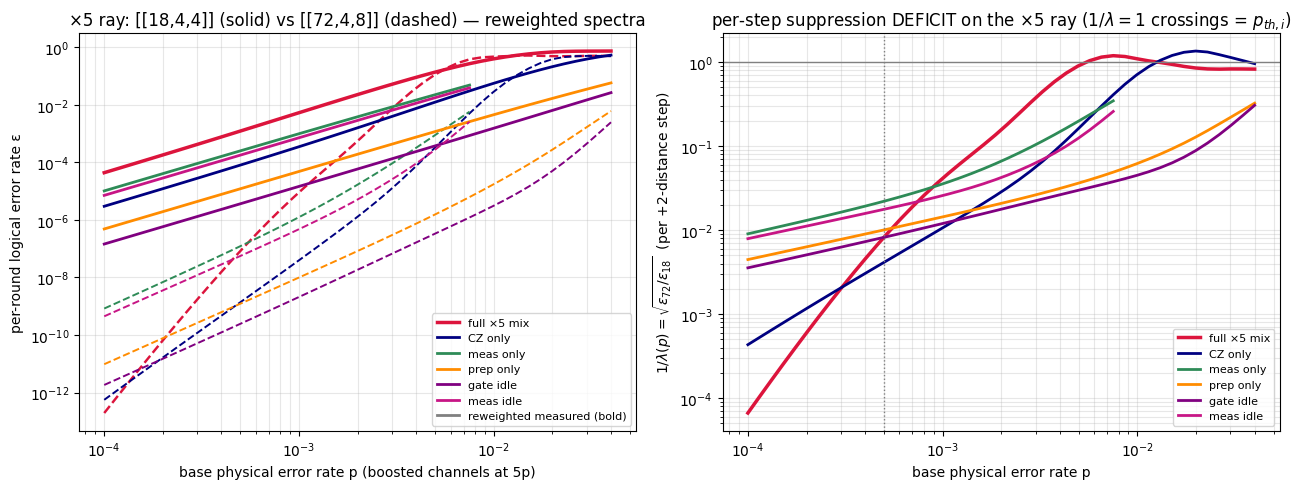

In [25]:
R.fig_84()   # the §7.4 panels on the ×5 ray, same bold/faint convention

### §8.5 — the marginal curves: which channel limits what, where (both rays)

§8.4's panels show channel-**isolated** curves (intrinsic capability; their crossings are the
per-channel thresholds). These are the leave-one-out **marginal** curves — the §7.5/§8 budget and
Λ boxes turned into functions of `p`, entirely from cached ablation spectra (no new sampling) —
drawn for **both operating points**: the first figure is the **symmetric ray** (the §5/§7.5
ablations), the second the **×5 ray** (the §8 asymmetric ablations). Left panels: the LER marginal
fraction `1 − LER_no-i/LER_full` per code (solid [[18,4,4]], dashed [[72,4,8]]). Right panels:
each channel's share of the suppression deficit, `(1/Λ_full − 1/Λ_no-i)/(1/Λ_full)`. Read the two
figures together — they are the gradient of the budget at the two base points, and their
difference is the §8 rotation story at a glance: on the symmetric ray CZ leads everywhere; on the
×5 ray the small code's error rate turns meas-type-limited (meas & meas-idle take over the left
panel's solid curves) while the big code — and with it the Λ deficit — stays CZ-led (right
panel). Curves get noisy where the 72-code spectra are onset-limited (low `p`, dashed curves and
the right panels); the §7.5/§8 boxes at `p*` carry the honest `±σ` for exactly these quantities —
a share is only *real* if it verdicts solid there. The dotted vertical line marks `p*`.

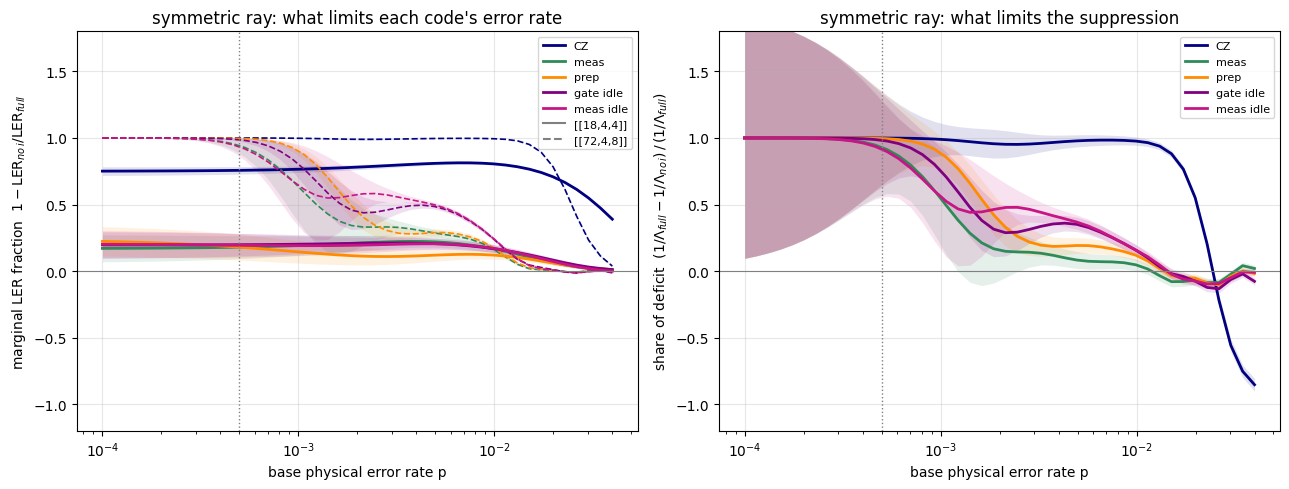

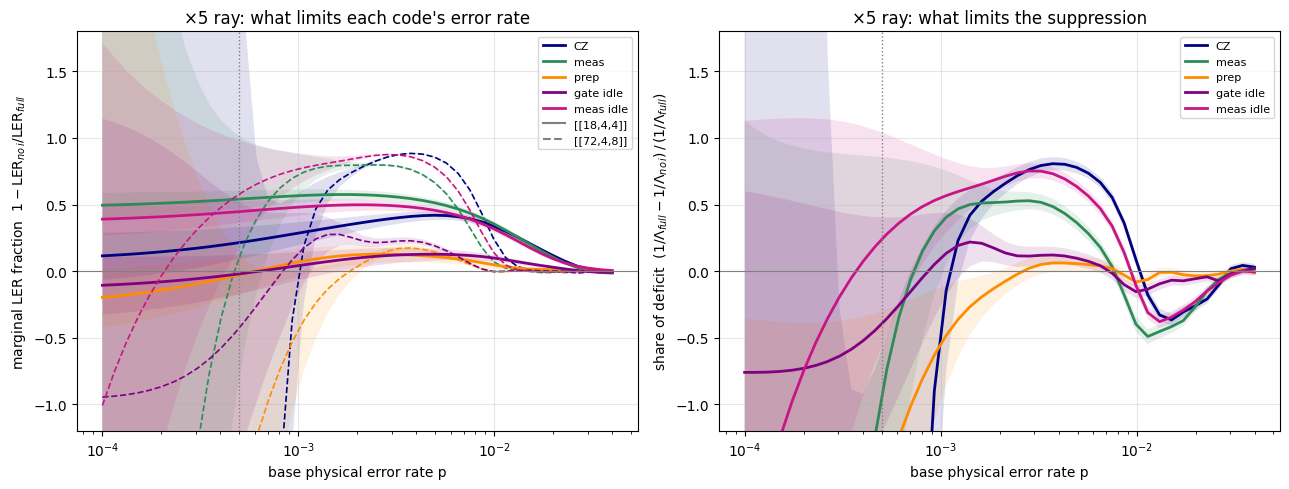

In [26]:
R.fig_85()   # marginal (leave-one-out) curves, symmetric ray then ×5 ray

## Takeaways

* **The full-circuit distance-3 reduction needs *mixed* error types.** `CZ only`, `meas only`,
  `prep only`, and `idle only` are each distance **4** (the code distance); only *combining* channels
  produces the weight-3 hook that drops the full model to `D=3`.
* **Two-qubit (CZ) gate errors dominate** the logical error rate; the single-location channels
  (**measurement, preparation, idle-data**) are each far smaller — fewer DEM mechanisms and much lower
  LER — and the full LER sits well above the sum of the isolated channels, i.e. the mixed-type faults
  carry most of it.
* **Preparation vs. measurement:** reset and measurement bit-flips are the same `X_ERROR` at the same
  rate, but split by circuit position they can contribute differently — compare the `prep only` and
  `meas only` curves.
* **The techniques agree with direct MC for every model** and extrapolate together into the rare regime:
  the fail-fast toolkit works channel-by-channel, not just on the full model.
* Both onset routes appear in one comparison: the isolated channels are **even distance 4** (exact `f₀*`
  via Proposition 1), the full model is **odd distance 3** (Appendix A.6).
* **Isolated ≠ marginal (§5–§6).** The channel-only circuits miss the mixed-type faults entirely, so
  their fractions under-count and leave a **mixing bucket**; the leave-one-out marginals (Google's
  convention) count each mixed fault once per participant, so they **over-count** (Σ > 1). The gap
  between the two decompositions *is* the mixed-fault structure — read it together with the ablated
  distances, which name the channels every weight-3 hook needs.
* **Pseudo-thresholds (§6) vs true thresholds (§7).** §6's break-even points need only one code; §7
  replaces them with the real thing — the `ε₁₈,ᵢ(p) = ε₇₂,ᵢ(p)` crossings against the same-polynomial
  sibling **[[72,4,8]]** — and reads off `Λ_i(p)` directly. With `d: 4→8` (two `+2` steps) the
  per-step suppression is `λ = √Λ_full`.
* **The Willow identity `1/Λ ≈ Σᵢ p/p_th,i` is the §7 punchline**: how far the sum falls short of
  `1/Λ_full` measures exactly how much the mixed-channel faults (the §1 `D=3` hook, invisible to
  every isolated channel) break the additive budget.
* **Λ shares are differences of noisy ratios — trust only flagged-solid signs (§7.5, §8).** Each
  marginal contribution now carries a propagated `±σ` and a zero-bin truncation interval; a negative
  share that is `~0 within 2σ` or `not robust to zero-bin truncation` is an artifact of the
  under-resolved 72-code onset bins, not physics. `--boost72` in the runner tightens exactly those
  spectra (and the cache means nothing else reruns).
* **The whole budget is a gradient at a base point (§8).** Re-evaluating at a device-like ray
  (meas + meas-idle ×5) shows how the decomposition rotates with the noise mix. The isolated
  basis reweights analytically to any rate vector (`f(w)` is rate-independent); only the full and
  ablated mixes need resampling — which is what makes multi-point sensitivity maps affordable.

*Report generated by `make_error_model_comparison.py`; data by `run_error_model_comparison.py`
(cached per task under `runs/error_model_comparison_18_4_4/`).*